In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras

(X_train, y_train), (X_test, y_test) = keras.datasets.fashion_mnist.load_data()

print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)
print('GPU available:', tf.config.list_physical_devices('GPU'))

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
(60000, 28, 28) (60000,)
(10000, 28, 28) (10000,)
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


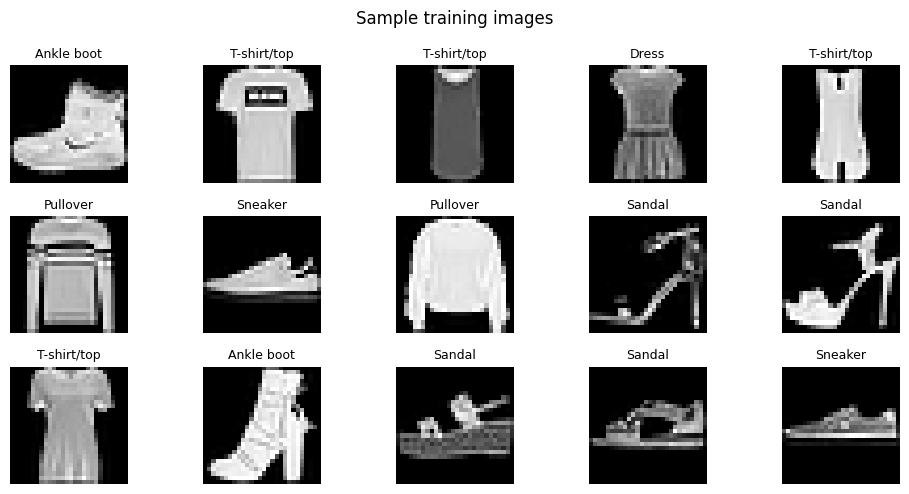

Ankle boot     6000
T-shirt/top    6000
Dress          6000
Pullover       6000
Sneaker        6000
Sandal         6000
Trouser        6000
Shirt          6000
Coat           6000
Bag            6000
Name: count, dtype: int64
Pixel range: 0 to 255


In [2]:
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

plt.figure(figsize=(10, 5))
for i in range(15):
    plt.subplot(3, 5, i + 1)
    plt.imshow(X_train[i], cmap='gray')
    plt.title(class_names[y_train[i]], fontsize=9)
    plt.axis('off')
plt.suptitle('Sample training images')
plt.tight_layout()
plt.show()

print(pd.Series(y_train).map(dict(enumerate(class_names))).value_counts())
print('Pixel range:', X_train.min(), 'to', X_train.max())

In [3]:
X_train_s = X_train.astype('float32') / 255.0
X_test_s = X_test.astype('float32') / 255.0

X_train_s = X_train_s[..., np.newaxis]
X_test_s = X_test_s[..., np.newaxis]

print(X_train_s.shape, X_test_s.shape)
print('New range:', X_train_s.min(), 'to', X_train_s.max())

(60000, 28, 28, 1) (10000, 28, 28, 1)
New range: 0.0 to 1.0


In [4]:
from tensorflow.keras import layers

tf.random.set_seed(42)

dense_model = keras.Sequential([
    keras.Input(shape=(28, 28, 1)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

dense_model.compile(optimizer='adam',
                    loss='sparse_categorical_crossentropy',
                    metrics=['accuracy'])

dense_model.summary()

history_dense = dense_model.fit(X_train_s, y_train, epochs=15,
                                validation_split=0.1, batch_size=128, verbose=2)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
422/422 - 5s - 12ms/step - accuracy: 0.8032 - loss: 0.5734 - val_accuracy: 0.8362 - val_loss: 0.4566
Epoch 2/15
422/422 - 2s - 4ms/step - accuracy: 0.8545 - loss: 0.4172 - val_accuracy: 0.8537 - val_loss: 0.4143
Epoch 3/15
422/422 - 2s - 4ms/step - accuracy: 0.8682 - loss: 0.3742 - val_accuracy: 0.8642 - val_loss: 0.3867
Epoch 4/15
422/422 - 1s - 3ms/step - accuracy: 0.8768 - loss: 0.3464 - val_accuracy: 0.8708 - val_loss: 0.3669
Epoch 5/15
422/422 - 1s - 3ms/step - accuracy: 0.8828 - loss: 0.3263 - val_accuracy: 0.8740 - val_loss: 0.3543
Epoch 6/15
422/422 - 1s - 3ms/step - accuracy: 0.8880 - loss: 0.3104 - val_accuracy: 0.8767 - val_loss: 0.3463
Epoch 7/15
422/422 - 1s - 3ms/step - accuracy: 0.8935 - loss: 0.2967 - val_accuracy: 0.8772 - val_loss: 0.3448
Epoch 8/15
422/422 - 1s - 3ms/step - accuracy: 0.8976 - loss: 0.2845 - val_accuracy: 0.8792 - val_loss: 0.3405
Epoch 9/15
422/422 - 1s - 3ms/step - accuracy: 0.9014 - loss: 0.2738 - val_accuracy: 0.8830 - val_loss: 0.3337


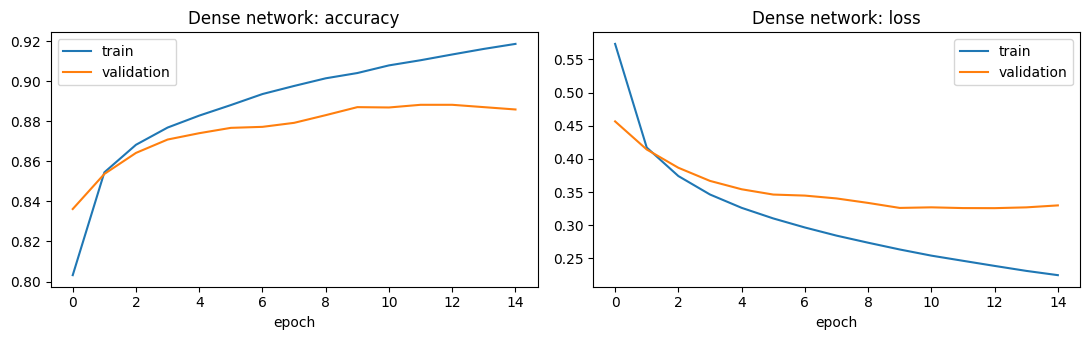

,model,parameters,epochs_trained,final_train_acc,best_val_acc,test_acc,test_loss
0,Dense NN,101770,15,0.9186,0.8882,0.8834,0.3456


In [5]:
results = []

def evaluate(name, model, history):
    test_loss, test_acc = model.evaluate(X_test_s, y_test, verbose=0)
    results.append({
        'model': name,
        'parameters': model.count_params(),
        'epochs_trained': len(history.history['loss']),
        'final_train_acc': history.history['accuracy'][-1],
        'best_val_acc': max(history.history['val_accuracy']),
        'test_acc': test_acc,
        'test_loss': test_loss
    })
    return pd.DataFrame(results).round(4)

def plot_history(history, title):
    fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
    ax[0].plot(history.history['accuracy'], label='train')
    ax[0].plot(history.history['val_accuracy'], label='validation')
    ax[0].set_title(f'{title}: accuracy'); ax[0].set_xlabel('epoch'); ax[0].legend()
    ax[1].plot(history.history['loss'], label='train')
    ax[1].plot(history.history['val_loss'], label='validation')
    ax[1].set_title(f'{title}: loss'); ax[1].set_xlabel('epoch'); ax[1].legend()
    plt.tight_layout(); plt.show()

plot_history(history_dense, 'Dense network')
evaluate('Dense NN', dense_model, history_dense)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       401,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 421,642 (1.61 MB)

 Trainable params: 421,642 (1.61 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
422/422 - 9s - 21ms/step - accuracy: 0.8199 - loss: 0.4993 - val_accuracy: 0.8752 - val_loss: 0.3491
Epoch 2/15
422/422 - 2s - 5ms/step - accuracy: 0.8863 - loss: 0.3183 - val_accuracy: 0.8982 - val_loss: 0.2891
Epoch 3/15
422/422 - 2s - 5ms/step - accuracy: 0.9003 - loss: 0.2752 - val_accuracy: 0.9030 - val_loss: 0.2749
Epoch 4/15
422/422 - 2s - 5ms/step - accuracy: 0.9115 - loss: 0.2452 - val_accuracy: 0.9080 - val_loss: 0.2595
Epoch 5/15
422/422 - 2s - 5ms/step - accuracy: 0.9204 - loss: 0.2205 - val_accuracy: 0.9112 - val_loss: 0.2535
Epoch 6/15
422/422 - 2s - 6ms/step - accuracy: 0.9279 - loss: 0.1997 - val_accuracy: 0.9138 - val_loss: 0.2438
Epoch 7/15
422/422 - 2s - 5ms/step - accuracy: 0.9346 - loss: 0.1817 - val_accuracy: 0.9193 - val_loss: 0.2316
Epoch 8/15
422/422 - 2s - 5ms/step - accuracy: 0.9417 - loss: 0.1640 - val_accuracy: 0.9185 - val_loss: 0.2295
Epoch 9/15
422/422 - 2s - 5ms/step - accuracy: 0.9476 - loss: 0.1478 - val_accuracy: 0.9220 - val_loss: 0.2283


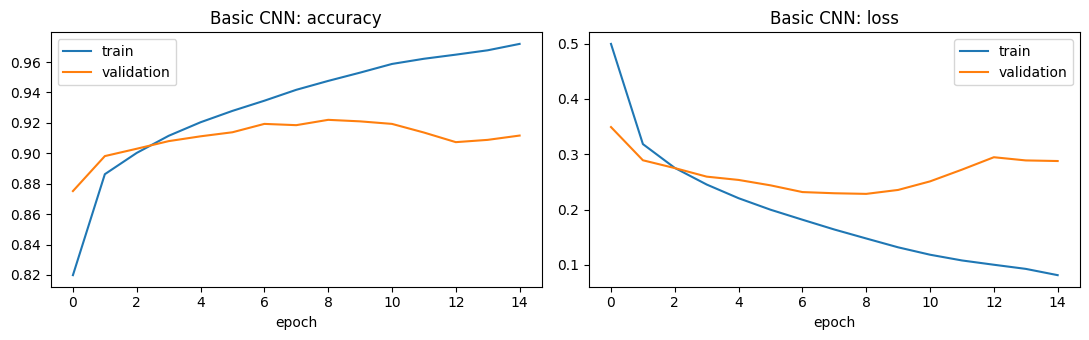

,model,parameters,epochs_trained,final_train_acc,best_val_acc,test_acc,test_loss
0,Dense NN,101770,15,0.9186,0.8882,0.8834,0.3456
1,Basic CNN,421642,15,0.9719,0.9220,0.9093,0.3143


In [6]:
tf.random.set_seed(42)

cnn_model = keras.Sequential([
    keras.Input(shape=(28, 28, 1)),
    layers.Conv2D(32, kernel_size=3, padding='same', activation='relu'),
    layers.MaxPooling2D(pool_size=2),
    layers.Conv2D(64, kernel_size=3, padding='same', activation='relu'),
    layers.MaxPooling2D(pool_size=2),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

cnn_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
cnn_model.summary()

history_cnn = cnn_model.fit(X_train_s, y_train, epochs=15,
                            validation_split=0.1, batch_size=128, verbose=2)

plot_history(history_cnn, 'Basic CNN')
evaluate('Basic CNN', cnn_model, history_cnn)

Epoch 1/40
422/422 - 14s - 32ms/step - accuracy: 0.7675 - loss: 0.6545 - val_accuracy: 0.6640 - val_loss: 1.3457
Epoch 2/40
422/422 - 2s - 6ms/step - accuracy: 0.8428 - loss: 0.4320 - val_accuracy: 0.8698 - val_loss: 0.3496
Epoch 3/40
422/422 - 2s - 6ms/step - accuracy: 0.8629 - loss: 0.3746 - val_accuracy: 0.9017 - val_loss: 0.2682
Epoch 4/40
422/422 - 2s - 6ms/step - accuracy: 0.8758 - loss: 0.3427 - val_accuracy: 0.8837 - val_loss: 0.3219
Epoch 5/40
422/422 - 2s - 6ms/step - accuracy: 0.8825 - loss: 0.3222 - val_accuracy: 0.8900 - val_loss: 0.3017
Epoch 6/40
422/422 - 3s - 7ms/step - accuracy: 0.8894 - loss: 0.3061 - val_accuracy: 0.8897 - val_loss: 0.3053
Epoch 7/40
422/422 - 5s - 11ms/step - accuracy: 0.8950 - loss: 0.2897 - val_accuracy: 0.9080 - val_loss: 0.2480
Epoch 8/40
422/422 - 2s - 6ms/step - accuracy: 0.8964 - loss: 0.2821 - val_accuracy: 0.8920 - val_loss: 0.3004
Epoch 9/40
422/422 - 2s - 6ms/step - accuracy: 0.9019 - loss: 0.2715 - val_accuracy: 0.9095 - val_loss: 0.262

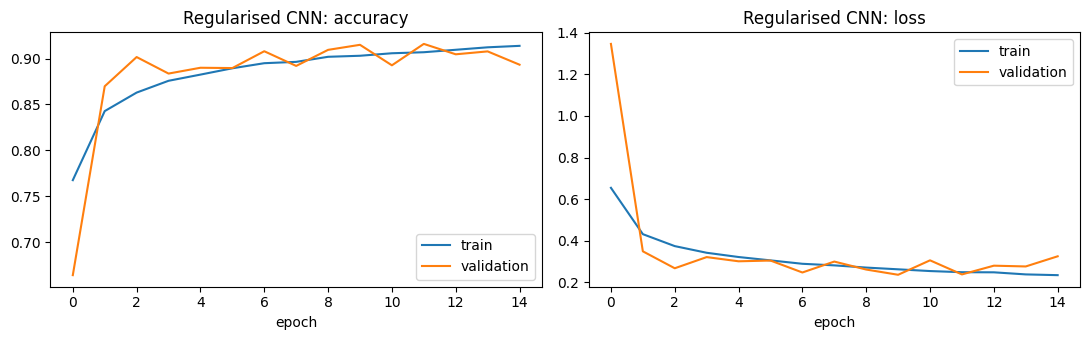

,model,parameters,epochs_trained,final_train_acc,best_val_acc,test_acc,test_loss
0,Dense NN,101770,15,0.9186,0.8882,0.8834,0.3456
1,Basic CNN,421642,15,0.9719,0.9220,0.9093,0.3143
2,Regularised CNN (BatchNorm + Dropout + EarlySt...,422026,15,0.9139,0.9160,0.9095,0.2691


In [7]:
tf.random.set_seed(42)

reg_cnn = keras.Sequential([
    keras.Input(shape=(28, 28, 1)),
    layers.Conv2D(32, kernel_size=3, padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(pool_size=2),
    layers.Dropout(0.25),

    layers.Conv2D(64, kernel_size=3, padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(pool_size=2),
    layers.Dropout(0.25),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

reg_cnn.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

early_stop = keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history_reg = reg_cnn.fit(X_train_s, y_train, epochs=40,
                          validation_split=0.1, batch_size=128,
                          callbacks=[early_stop], verbose=2)

plot_history(history_reg, 'Regularised CNN')
evaluate('Regularised CNN (BatchNorm + Dropout + EarlyStopping)', reg_cnn, history_reg)

Epoch 1/60
422/422 - 13s - 30ms/step - accuracy: 0.7684 - loss: 0.6549 - val_accuracy: 0.5488 - val_loss: 1.9759 - learning_rate: 0.0010
Epoch 2/60
422/422 - 3s - 7ms/step - accuracy: 0.8389 - loss: 0.4455 - val_accuracy: 0.8788 - val_loss: 0.3213 - learning_rate: 0.0010
Epoch 3/60
422/422 - 2s - 6ms/step - accuracy: 0.8630 - loss: 0.3771 - val_accuracy: 0.8893 - val_loss: 0.3042 - learning_rate: 0.0010
Epoch 4/60
422/422 - 2s - 6ms/step - accuracy: 0.8756 - loss: 0.3412 - val_accuracy: 0.9033 - val_loss: 0.2638 - learning_rate: 0.0010
Epoch 5/60
422/422 - 2s - 6ms/step - accuracy: 0.8826 - loss: 0.3212 - val_accuracy: 0.9063 - val_loss: 0.2480 - learning_rate: 0.0010
Epoch 6/60
422/422 - 2s - 6ms/step - accuracy: 0.8893 - loss: 0.3041 - val_accuracy: 0.9073 - val_loss: 0.2605 - learning_rate: 0.0010
Epoch 7/60
422/422 - 3s - 7ms/step - accuracy: 0.8945 - loss: 0.2898 - val_accuracy: 0.8983 - val_loss: 0.2787 - learning_rate: 0.0010
Epoch 8/60
422/422 - 2s - 6ms/step - accuracy: 0.8991

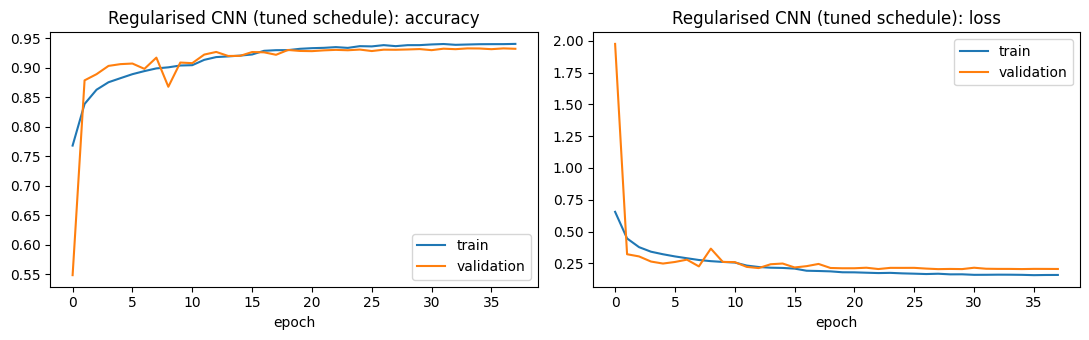

,model,parameters,epochs_trained,final_train_acc,best_val_acc,test_acc,test_loss
0,Dense NN,101770,15,0.9186,0.8882,0.8834,0.3456
1,Basic CNN,421642,15,0.9719,0.9220,0.9093,0.3143
2,Regularised CNN (BatchNorm + Dropout + EarlySt...,422026,15,0.9139,0.9160,0.9095,0.2691
3,Regularised CNN + LR schedule,422026,38,0.9406,0.9330,0.9298,0.2251


In [8]:
tf.random.set_seed(42)

reg_cnn_tuned = keras.models.clone_model(reg_cnn)
reg_cnn_tuned.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

callbacks = [
    keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-5, verbose=1)
]

history_tuned = reg_cnn_tuned.fit(X_train_s, y_train, epochs=60,
                                  validation_split=0.1, batch_size=128,
                                  callbacks=callbacks, verbose=2)

plot_history(history_tuned, 'Regularised CNN (tuned schedule)')
evaluate('Regularised CNN + LR schedule', reg_cnn_tuned, history_tuned)

              precision    recall  f1-score   support

 T-shirt/top      0.886     0.896     0.891      1000
     Trouser      0.996     0.988     0.992      1000
    Pullover      0.900     0.897     0.898      1000
       Dress      0.920     0.931     0.925      1000
        Coat      0.891     0.897     0.894      1000
      Sandal      0.993     0.984     0.988      1000
       Shirt      0.781     0.771     0.776      1000
     Sneaker      0.963     0.981     0.972      1000
         Bag      0.991     0.983     0.987      1000
  Ankle boot      0.978     0.970     0.974      1000

    accuracy                          0.930     10000
   macro avg      0.930     0.930     0.930     10000
weighted avg      0.930     0.930     0.930     10000



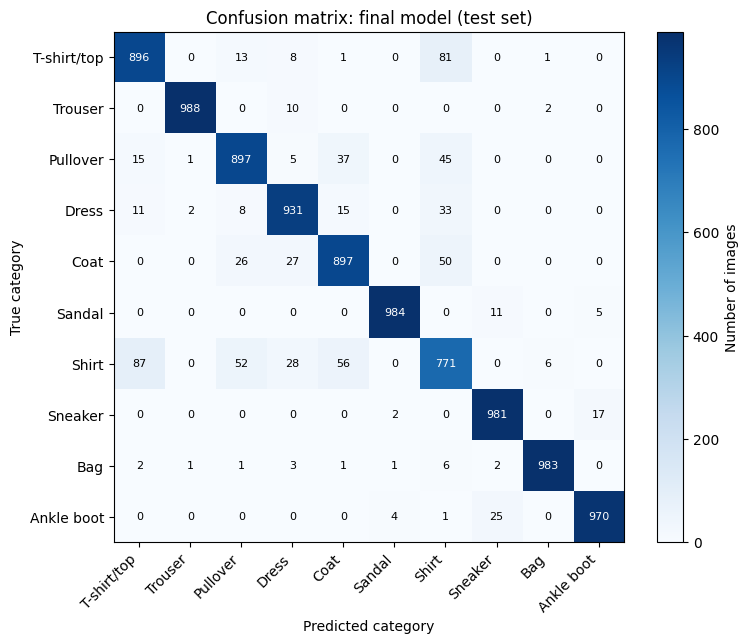

Share of predictions with confidence < 70%: 6.5 %
Accuracy on confident predictions (>= 70%): 95.9 %


In [9]:
from sklearn.metrics import classification_report, confusion_matrix

y_prob = reg_cnn_tuned.predict(X_test_s, verbose=0)
y_pred = y_prob.argmax(axis=1)

print(classification_report(y_test, y_pred, target_names=class_names, digits=3))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6.5))
plt.imshow(cm, cmap='Blues')
plt.colorbar(label='Number of images')
plt.xticks(range(10), class_names, rotation=45, ha='right')
plt.yticks(range(10), class_names)
for i in range(10):
    for j in range(10):
        plt.text(j, i, cm[i, j], ha='center', va='center',
                 color='white' if cm[i, j] > 500 else 'black', fontsize=8)
plt.xlabel('Predicted category'); plt.ylabel('True category')
plt.title('Confusion matrix: final model (test set)')
plt.tight_layout(); plt.show()

confidence = y_prob.max(axis=1)
print('Share of predictions with confidence < 70%:', round((confidence < 0.7).mean() * 100, 1), '%')
print('Accuracy on confident predictions (>= 70%):', round((y_pred[confidence >= 0.7] == y_test[confidence >= 0.7]).mean() * 100, 1), '%')
